### *Import Library*

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import pyfeats
import joblib
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score


### *Preprocessing Data*

In [2]:
# =============================================
# Preprocessing Data (Grayscale, Resize, CLAHE)
# =============================================
input_dirs = {
    'Normal': 'C:/SKRIPSI/Dataset/NORMAL',
    'Covid19': 'C:/SKRIPSI/Dataset/COVID19'
}
label_map = {'Normal': 0, 'Covid19': 1}

processed_images = []
labels = []

for label, folder in input_dirs.items():
    for fname in tqdm(os.listdir(folder), desc=f"Preprocessing {label}"):
        if fname.lower().endswith(('jpg', 'jpeg', 'png')):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img = clahe.apply(img)
            processed_images.append(img)
            labels.append(label_map[label])

Preprocessing Covid19: 100%|██████████| 1000/1000 [00:47<00:00, 21.13it/s]


### *Ekstraksi Fitur*

In [3]:
# ===============================
# Ekstraksi Fitur FOS
# ===============================
fos_list = []
for img in tqdm(processed_images, desc="Ekstraksi FOS"):
    mask = np.ones_like(img)
    fos, _ = pyfeats.fos(img, mask)
    fos_list.append(fos[:10])

fos_df = pd.DataFrame(fos_list, columns=[
    'FOS_Mean', 'FOS_StdDev', 'FOS_Median', 'FOS_Mode', 'FOS_Skewness',
    'FOS_Kurtosis', 'FOS_Energy', 'FOS_Entropy', 'FOS_Min', 'FOS_Max'])
fos_df.insert(0, 'Label', labels)

# print("\n✅ Ekstraksi FOS selesai")
# print(fos_df.head())

# fos_df.to_csv("fitur_fos.csv", index=False)

Ekstraksi FOS: 100%|██████████| 2000/2000 [00:57<00:00, 34.50it/s]


In [4]:
# ===============================
# Ekstraksi Fitur GLCM
# ===============================
glcm_list = []
for img in tqdm(processed_images, desc="Ekstraksi GLCM"):
    glcm = pyfeats.glcm_features(img)
    combined = np.concatenate([glcm[0], glcm[1]])
    drop = [i for i in [12, 13, 14, 20, 26, 27, 28] if i < len(combined)]
    glcm_filtered = np.delete(combined, drop)
    glcm_list.append(glcm_filtered)

glcm_df = pd.DataFrame(glcm_list, columns=[
    'GLCM_ASM_Mean', 'GLCM_Contrast_Mean', 'GLCM_Correlation_Mean', 'GLCM_SumOfSquaresVariance_Mean',
    'GLCM_InverseDifferenceMoment_Mean', 'GLCM_SumAverage_Mean', 'GLCM_SumVariance_Mean', 'GLCM_SumEntropy_Mean',
    'GLCM_Entropy_Mean', 'GLCM_DifferenceVariance_Mean', 'GLCM_DifferenceEntropy_Mean',
    'GLCM_ASM_Range', 'GLCM_Contrast_Range', 'GLCM_Correlation_Range', 'GLCM_SumOfSquaresVariance_Range',
    'GLCM_InverseDifferenceMoment_Range', 'GLCM_SumAverage_Range', 'GLCM_SumVariance_Range', 'GLCM_SumEntropy_Range',
    'GLCM_Entropy_Range', 'GLCM_DifferenceVariance_Range', 'GLCM_DifferenceEntropy_Range'])
glcm_df.insert(0, 'Label', labels)

# print("\n✅ Ekstraksi GLCM selesai")
# # print(glcm_df.head())

# glcm_df.to_csv("fitur_glcm.csv", index=False)

Ekstraksi GLCM: 100%|██████████| 2000/2000 [04:03<00:00,  8.23it/s]


In [5]:
# ===============================
# 🔗 4. Gabungkan Fitur
# ===============================
fos_only = fos_df.drop(columns=['Label'])
glcm_only = glcm_df.drop(columns=['Label'])
combined_df = pd.concat([pd.Series(labels, name='Label'), fos_only, glcm_only], axis=1)

print("\n✅ Fitur gabungan FOS + GLCM")
print(combined_df.head())

# combined_df.to_csv("fitur_gabungan.csv", index=False)


✅ Fitur gabungan FOS + GLCM
   Label    FOS_Mean   FOS_StdDev  FOS_Median  FOS_Mode  FOS_Skewness  \
0      0  112.824370  4346.547992       123.0       3.0     -0.318103   
1      0  124.883653  4319.154064       134.0       3.0     -0.387310   
2      0  122.092057  3778.430125       130.0       3.0     -0.462468   
3      0  118.126271  4619.415486       134.0       3.0     -0.455504   
4      0  126.809044  4788.230094       136.0       3.0     -0.325993   

   FOS_Kurtosis  FOS_Energy  FOS_Entropy  FOS_Min  ...  GLCM_Contrast_Range  \
0      1.970947    0.020079     5.065428      1.0  ...           255.993106   
1      2.156233    0.012142     5.221730      2.0  ...           224.216249   
2      2.316424    0.011096     5.181832      1.0  ...           239.847204   
3      2.004919    0.020965     5.018553      2.0  ...           224.389462   
4      2.048583    0.012372     5.257357      2.0  ...           212.557083   

   GLCM_Correlation_Range  GLCM_SumOfSquaresVariance_Rang

### *Feature removal*

In [6]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from scipy.stats import zscore
import joblib

# ===== Custom Transformer =====
class ZScoreMasking(BaseEstimator, TransformerMixin):
    def __init__(self, mask=None):
        self.mask = mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.mask is None:
            return X
        return X[:, self.mask]

# ===== Load Dataset =====
X = combined_df.drop(columns=['Label']).values
y = combined_df['Label'].values
feature_names = combined_df.drop(columns=['Label']).columns

print("\n📊 Jumlah fitur awal:", X.shape[1])

# ===== Hitung Statistik =====
z = np.abs(zscore(X))
mean_z = z.mean(axis=0)
var = X.var(axis=0)

print("\n🔍 Statistik per fitur:")
for i, name in enumerate(feature_names):
    print(f"  {name:20} | mean_z: {mean_z[i]:.4f} | var: {var[i]:.6f}")

# ===== Grid Threshold Setup =====
thresh_range = np.arange(0.5, 4.5, 0.25)
param_grid = []
mask_dict = {}

for t in thresh_range:
    mask = (mean_z < t) & (var > 1e-5)
    selected = np.where(mask)[0]

    if len(selected) > 1:
        corr = np.corrcoef(X[:, selected].T)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                if abs(corr[i, j]) > 0.95:
                    if mean_z[selected[i]] > mean_z[selected[j]]:
                        mask[selected[i]] = False
                    else:
                        mask[selected[j]] = False

    mask_dict[t] = mask
    print(f"📌 Threshold: {t:.2f} | Fitur tersisa: {mask.sum()}")

    param_grid.append({
        'mask__mask': [mask],
        'svc__C': [0.1, 1.0, 10.0]
    })

# ===== Build Pipeline =====
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mask', ZScoreMasking()),
    ('svc', LinearSVC(max_iter=100000, dual=False))
])

# ===== GridSearch =====
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

# ===== Ambil Kombinasi dengan Fitur < Penuh =====
results = grid.cv_results_
filtered = [
    (i, params['mask__mask'])
    for i, params in enumerate(results['params'])
    if params['mask__mask'].sum() < X.shape[1]
]

if filtered:
    # Ambil skor tertinggi di antara konfigurasi yang mengurangi fitur
    best_i, best_mask = max(
        filtered,
        key=lambda x: results['mean_test_score'][x[0]]
    )
    best_threshold = [
        t for t, m in mask_dict.items() if np.array_equal(m, best_mask)
    ][0]
    best_pipeline = grid.cv_results_['params'][best_i]
    final_model = grid.best_estimator_
else:
    # Tidak ada fitur yang terfilter → fallback
    best_mask = grid.best_params_['mask__mask']
    best_threshold = [t for t, m in mask_dict.items() if np.array_equal(m, best_mask)][0]
    final_model = grid.best_estimator_

X_filtered = X[:, best_mask]

# ===== Output Hasil =====
print("\n✅ Threshold terbaik:", best_threshold)
print("📊 Jumlah fitur sebelum masking:", X.shape[1])
print("✅ Jumlah fitur setelah masking:", X_filtered.shape[1])
print("✅ Fitur yang dipertahankan:", feature_names[best_mask].tolist())



📊 Jumlah fitur awal: 32

🔍 Statistik per fitur:
  FOS_Mean             | mean_z: 0.7864 | var: 233.221111
  FOS_StdDev           | mean_z: 0.7894 | var: 1160780.867478
  FOS_Median           | mean_z: 0.7683 | var: 296.094758
  FOS_Mode             | mean_z: 0.9370 | var: 8222.991400
  FOS_Skewness         | mean_z: 0.7398 | var: 0.054290
  FOS_Kurtosis         | mean_z: 0.7215 | var: 0.176800
  FOS_Energy           | mean_z: 0.5371 | var: 0.000073
  FOS_Entropy          | mean_z: 0.7546 | var: 0.025139
  FOS_Min              | mean_z: 0.4732 | var: 21.119000
  FOS_Max              | mean_z: 0.4373 | var: 51.158778
  GLCM_ASM_Mean        | mean_z: 0.5529 | var: 0.000069
  GLCM_Contrast_Mean   | mean_z: 0.7328 | var: 28300.648428
  GLCM_Correlation_Mean | mean_z: 0.6269 | var: 0.000789
  GLCM_SumOfSquaresVariance_Mean | mean_z: 0.7883 | var: 1138133.249522
  GLCM_InverseDifferenceMoment_Mean | mean_z: 0.7654 | var: 0.002849
  GLCM_SumAverage_Mean | mean_z: 0.7860 | var: 919.145344
  GL

### *Normalisasi*

In [7]:
# ===============================
# ⚙️ 6. Split & Normalisasi
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### *Modeling*

Fitting 5 folds for each of 55 candidates, totalling 275 fits

✅ Parameter Terbaik: {'C': 100.0, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}
✅ Akurasi CV Terbaik: 0.9750
✅ Akurasi pada data uji: 0.9825

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       200
     Covid19       0.98      0.98      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



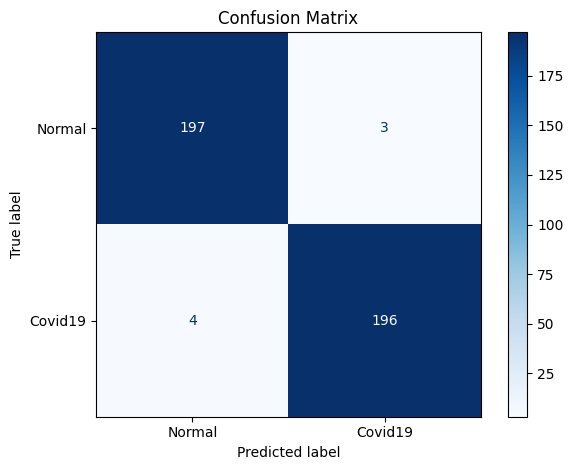

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

# ------------------------
# Parameter Grid SVM
# ------------------------
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 1.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto'],
        'class_weight': ['balanced']
    }
]

# ------------------------
# Grid Search CV
# ------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

# ------------------------
# Tampilkan hasil terbaik
# ------------------------
print("\n✅ Parameter Terbaik:", grid.best_params_)
print(f"✅ Akurasi CV Terbaik: {grid.best_score_:.4f}")

# ------------------------
# Evaluasi di Test Data
# ------------------------
model = grid.best_estimator_
test_acc = model.score(X_test_scaled, y_test)
print(f"✅ Akurasi pada data uji: {test_acc:.4f}")

y_pred = model.predict(X_test_scaled)

# Tambahkan label_names
label_names = list(label_map.keys())  # Fix error di sini

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# ============================
# 📉 Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### *CV Result*

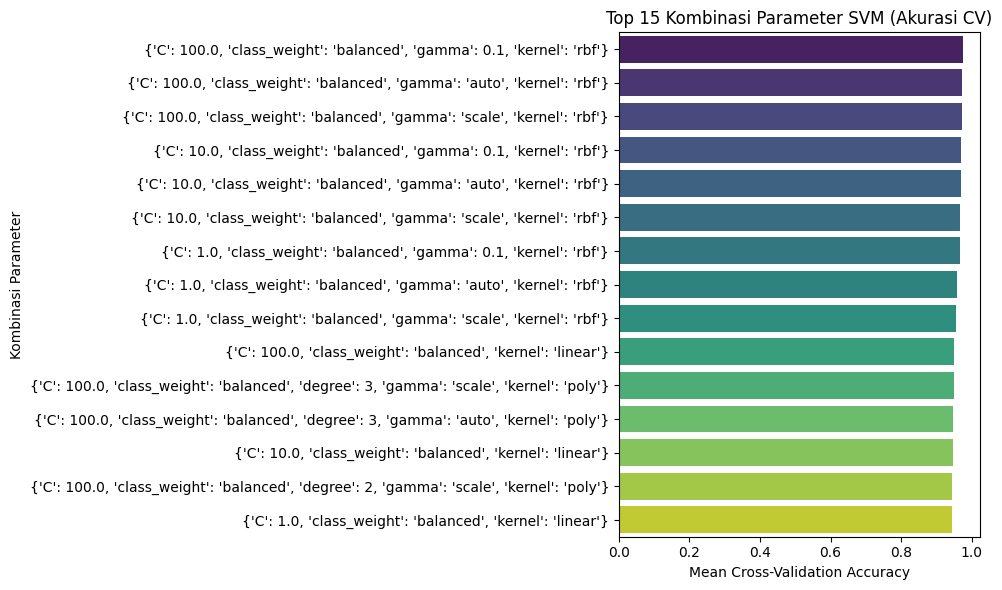

In [9]:
import seaborn as sns

# Ambil hasil grid search dalam DataFrame
cv_results = pd.DataFrame(grid.cv_results_)

# Gabungkan parameter menjadi string
cv_results["params_str"] = cv_results["params"].astype(str)

# Urutkan berdasarkan skor tertinggi
top_cv = cv_results.sort_values(by="mean_test_score", ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cv, x="mean_test_score", y="params_str", hue="params_str", dodge=False, palette="viridis", legend=False)
plt.title("Top 15 Kombinasi Parameter SVM (Akurasi CV)")
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Kombinasi Parameter")
plt.tight_layout()
plt.show()


### *Classification Report Metrics*

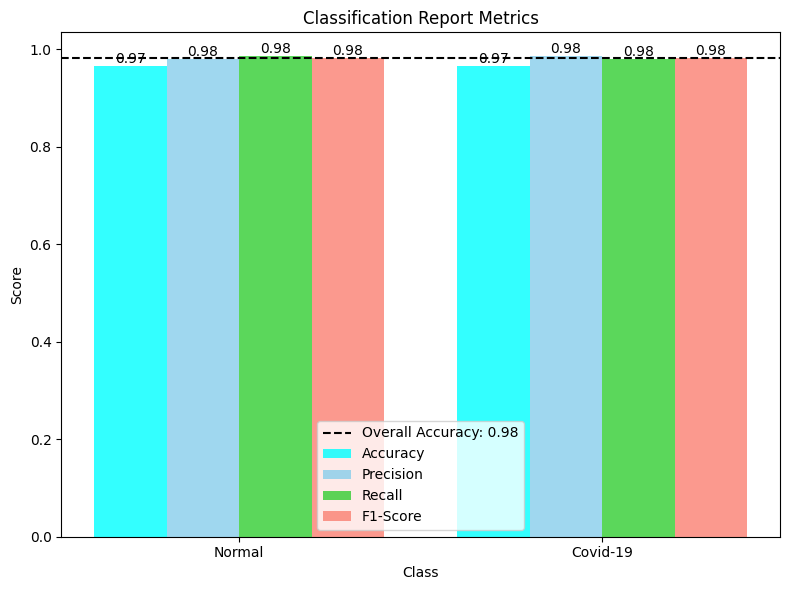


📊 Akurasi per kelas:
Kelas Normal: 0.97
Kelas Covid-19: 0.97
📊 Precision: [0.9800995  0.98492462]
📊 Recall: [0.985 0.98 ]
📊 F1-Score: [0.98254364 0.98245614]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Pastikan y_test hanya berisi dua kelas (misalnya 0 dan 1)
unique_classes = np.unique(y_test)
if len(unique_classes) != 2:
    raise ValueError("y_test harus berisi hanya dua kelas untuk klasifikasi biner. Gunakan multiclass jika lebih dari dua kelas.")

# Hitung prediksi
y_pred = model.predict(X_test_scaled)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

# Hitung akurasi per kelas
accuracy_per_class = []
for i in range(len(unique_classes)):
    tp = cm[i, i]
    fp = sum(cm[:, i]) - tp
    fn = sum(cm[i, :]) - tp
    acc_class = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    accuracy_per_class.append(acc_class)

# Hitung precision, recall, dan f1-score untuk kedua kelas
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None, labels=unique_classes)
accuracy = model.score(X_test_scaled, y_test)

# Data untuk grafik
classes = ['Normal', 'Covid-19']  # 
accuracy_values = accuracy_per_class
precision_values = precision
recall_values = recall
f1_score_values = f1

# Plot grafik batang
fig, ax = plt.subplots(figsize=(8, 6))
bar_width = 0.2
index = np.arange(len(classes))

bars1 = ax.bar(index, accuracy_values, bar_width, label='Accuracy', color='cyan', alpha=0.8)
bars2 = ax.bar(index + bar_width, precision_values, bar_width, label='Precision', color='skyblue', alpha=0.8)
bars3 = ax.bar(index + 2 * bar_width, recall_values, bar_width, label='Recall', color='limegreen', alpha=0.8)
bars4 = ax.bar(index + 3 * bar_width, f1_score_values, bar_width, label='F1-Score', color='salmon', alpha=0.8)

# Garis dashed untuk rata-rata accuracy
ax.axhline(y=accuracy, color='black', linestyle='--', label=f'Overall Accuracy: {accuracy:.2f}')

# Label dan judul
ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Classification Report Metrics')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(classes)
ax.legend()

# Tambahkan nilai di atas batang
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars4:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n📊 Akurasi per kelas:")
for i, class_name in enumerate(classes):
    print(f"Kelas {class_name}: {accuracy_per_class[i]:.2f}")
print(f"📊 Precision: {precision}")
print(f"📊 Recall: {recall}")
print(f"📊 F1-Score: {f1}")

### *AUC*

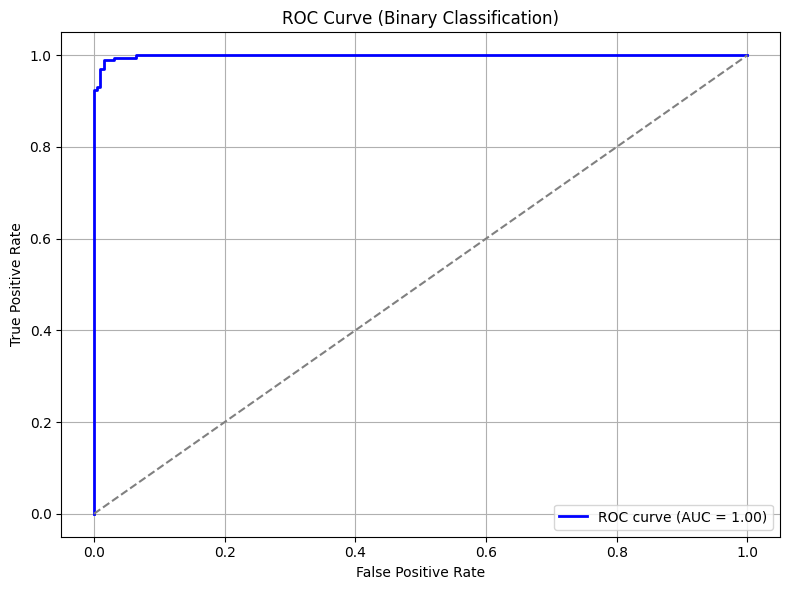

In [11]:
from sklearn.metrics import roc_curve, auc

# ROC Curve (untuk klasifikasi biner)
y_test_bin = label_binarize(y_test, classes=[0, 1]).ravel()
y_score = model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### *Save Model*

In [12]:
# # Simpan model dan tools
# joblib.dump(model, 'model_svm.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(best_mask, 'best_mask_kombinasi.pkl')
# print("\nModel dan file preprocessing berhasil disimpan!")